In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Smart Phone Price EDA


In [3]:
df = pd.read_csv("D:\CODES\Data Science\DATA\smartphone_prices - smartphone_prices.csv")
df.head()

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_3584\3733589082.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv("D:\CODES\Data Science\DATA\smartphone_prices - smartphone_prices.csv")


,brand,ram_gb,price
0,Samsung,4,15000
1,Apple,4,45000
2,OnePlus,6,30000
3,Samsung,6,18000
4,Apple,6,48000


In [4]:
df.describe()

,ram_gb,price
count,20.000000,20.000000
mean,7.400000,33525.000000
std,2.760625,13115.353598
min,4.000000,15000.000000
25%,6.000000,20750.000000
50%,7.000000,31500.000000
75%,8.000000,47250.000000
max,12.000000,52000.000000


In [5]:
df.isnull().sum()

brand     0
ram_gb    0
price     0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   brand   20 non-null     str  
 1   ram_gb  20 non-null     int64
 2   price   20 non-null     int64
dtypes: int64(2), str(1)
memory usage: 738.0 bytes


In [8]:
df_dummies = pd.get_dummies(df, columns=['brand'], dtype=int)
df_dummies

,ram_gb,price,brand_Apple,brand_OnePlus,brand_Samsung
0,4,15000,0,0,1
1,4,45000,1,0,0
2,6,30000,0,1,0
3,6,18000,0,0,1
4,6,48000,1,0,0
5,8,32000,0,1,0
6,8,20000,0,0,1
7,8,50000,1,0,0
8,12,35000,0,1,0
9,12,21000,0,0,1


In [7]:
df.head()

,brand,ram_gb,price
0,Samsung,4,15000
1,Apple,4,45000
2,OnePlus,6,30000
3,Samsung,6,18000
4,Apple,6,48000


In [9]:
df_dummies.head()

,ram_gb,price,brand_Apple,brand_OnePlus,brand_Samsung
0,4,15000,0,0,1
1,4,45000,1,0,0
2,6,30000,0,1,0
3,6,18000,0,0,1
4,6,48000,1,0,0


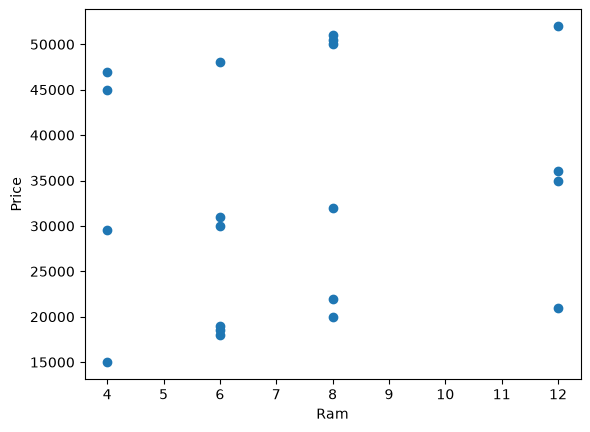

In [17]:
plt.scatter(x = df['ram_gb'],y=df['price'])
plt.xlabel("Ram")
plt.ylabel("Price")
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# warnings.filterwarnings('ignore')

In [13]:
df.head()

,brand,ram_gb,price
0,Samsung,4,15000
1,Apple,4,45000
2,OnePlus,6,30000
3,Samsung,6,18000
4,Apple,6,48000


In [15]:
df['brand_names'] = df['brand']
df.head()

,brand,ram_gb,price,brand_names
0,Samsung,4,15000,Samsung
1,Apple,4,45000,Apple
2,OnePlus,6,30000,OnePlus
3,Samsung,6,18000,Samsung
4,Apple,6,48000,Apple


In [14]:
df['brand'].unique()

<ArrowStringArray>
['Samsung', 'Apple', 'OnePlus']
Length: 3, dtype: str

In [16]:
df_dummies = pd.get_dummies(df, columns=['brand_names'], dtype=int)
df_dummies

,brand,ram_gb,price,brand_names_Apple,brand_names_OnePlus,brand_names_Samsung
0,Samsung,4,15000,0,0,1
1,Apple,4,45000,1,0,0
2,OnePlus,6,30000,0,1,0
3,Samsung,6,18000,0,0,1
4,Apple,6,48000,1,0,0
5,OnePlus,8,32000,0,1,0
6,Samsung,8,20000,0,0,1
7,Apple,8,50000,1,0,0
8,OnePlus,12,35000,0,1,0
9,Samsung,12,21000,0,0,1


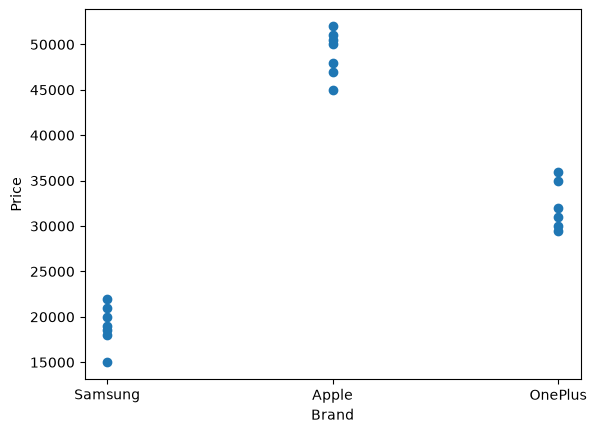

In [18]:
plt.scatter(x = df['brand'],y=df['price'])
plt.xlabel("Brand")
plt.ylabel("Price")
plt.show()

In [20]:
df_dummies = df_dummies.drop(columns=['brand_names_Samsung'])
df_dummies.head()

,brand,ram_gb,price,brand_names_Apple,brand_names_OnePlus
0,Samsung,4,15000,0,0
1,Apple,4,45000,1,0
2,OnePlus,6,30000,0,1
3,Samsung,6,18000,0,0
4,Apple,6,48000,1,0


In [22]:
model = LinearRegression()
X_test = df_dummies.drop(columns=["price","brand"])
y_test = df_dummies['price']
model.fit(X_test,y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 775.2 ,30000. ,12514.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['ram_gb','brand_names_Apple','brand_names_OnePlus']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.353e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [24]:
print("Model Coef :",model.coef_)
print("Model intercept :",model.intercept_)
print("R2 Score :",model.score(X_test,y_test))


Model Coef : [  775.2016129  30000.         12514.11290323]
Model intercept : 13534.274193548397
R2 Score : 0.9941429785635915


# One Hot Encoding

In [25]:
df.head()

,brand,ram_gb,price,brand_names
0,Samsung,4,15000,Samsung
1,Apple,4,45000,Apple
2,OnePlus,6,30000,OnePlus
3,Samsung,6,18000,Samsung
4,Apple,6,48000,Apple


In [28]:
X2 = df[['brand','ram_gb']]
y2 = df['price']

ct = ColumnTransformer(
    [
        ('brand_one',OneHotEncoder(drop='first'),['brand'])
    ],remainder='passthrough'
)

X2_encoded = ct.fit_transform(X2)
X2.head()

,brand,ram_gb
0,Samsung,4
1,Apple,4
2,OnePlus,6
3,Samsung,6
4,Apple,6


In [32]:

model_one = LinearRegression()
model_one.fit(X2_encoded,y2)
print("Model Coef :",model_one.coef_)
print("Model intercept :",model_one.intercept_)
print("R2 Score :",model_one.score(X2_encoded,y2))


Model Coef : [-17485.88709677 -30000.            775.2016129 ]
Model intercept : 43534.27419354842
R2 Score : 0.9941429785635915


In [34]:
pred = model_one.predict([[0, 1, 4]])
print(pred)

[16635.08064516]
